In [108]:
import pandas as pd
import numpy as np

df_model = pd.read_csv("nhanes_2017_2018_clean.csv")

print(df_model.shape)
print(df_model.head())

(4609, 15)
   sex   bmi  glucose  hba1c  total_cholesterol   hdl  systolic_bp  \
0  2.0  31.7     85.0    6.2              157.0  60.0   200.000000   
1  2.0  23.7    116.0    6.2              209.0  88.0   142.000000   
2  2.0  38.9     96.0    6.3              176.0  65.0   118.666667   
3  1.0  21.3     98.0    5.7              238.0  72.0   101.333333   
4  1.0  23.5     91.0    5.6              184.0  48.0   104.666667   

   diastolic_bp  albumin   alt   ast   ggt  creatinine   bun   age  
0     68.000000      4.4  16.0  20.0  21.0        0.92  11.0  66.0  
1     76.000000      3.9  19.0  21.0  22.0        0.58  16.0  66.0  
2     66.666667      3.7  15.0  17.0  31.0        1.32  20.0  75.0  
3     66.666667      4.0  20.0  23.0  19.0        1.13  14.0  56.0  
4     72.000000      4.3  18.0  18.0  26.0        1.13  22.0  67.0  


In [109]:
target = "age"

features = [
    "sex",
    "bmi",
    "glucose",
    "hba1c",
    "total_cholesterol",
    "hdl",
    "systolic_bp",
    "diastolic_bp",
    "albumin",
    "alt",
    "ast",
    "ggt",
    "creatinine",
    "bun"
]

X = df_model[features].copy()
y = df_model[target].copy()

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [111]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ["sex"]

numerical_features = [
    "bmi",
    "glucose",
    "hba1c",
    "total_cholesterol",
    "hdl",
    "systolic_bp",
    "diastolic_bp",
    "albumin",
    "alt",
    "ast",
    "ggt",
    "creatinine",
    "bun"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [112]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [113]:
y_pred_linear = linear_model.predict(X_test)

In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
-----------------
MAE : 10.791538436119147
RMSE: 13.295435257333748
R²  : 0.43121551151228654


In [115]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_linear],
    "RMSE": [rmse_linear],
    "R2": [r2_linear]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  10.791538  13.295435  0.431216


In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import SplineTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Categorical variable
categorical_features = ["sex"]

# Numerical variables
numerical_features = [
    "bmi",
    "glucose",
    "hba1c",
    "total_cholesterol",
    "hdl",
    "systolic_bp",
    "diastolic_bp",
    "albumin",
    "alt",
    "ast",
    "ggt",
    "creatinine",
    "bun"
]

# Preprocessing:
# Apply splines to numerical variables
# One-hot encode sex
gam_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SplineTransformer(
                n_knots=6,
                degree=3,
                include_bias=False
            ),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# GAM-style additive model
gam_model = Pipeline([
    ("preprocessor", gam_preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [117]:
gam_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [118]:
y_pred_gam = gam_model.predict(X_test)

In [119]:
# Show variables containing "gam"
[name for name in globals() if "gam" in name.lower()]

['gam_preprocessor',
 'gam_model',
 'y_pred_gam',
 'mae_gam',
 'rmse_gam',
 'r2_gam',
 'gam_cv',
 'gam_cv_mae',
 'gam_cv_rmse',
 'gam_cv_r2',
 'extract_gam_curves',
 'pre_gam_curves']

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gam = mean_absolute_error(y_test, y_pred_gam)

rmse_gam = np.sqrt(
    mean_squared_error(y_test, y_pred_gam)
)

r2_gam = r2_score(y_test, y_pred_gam)

print("GAM")
print("-----------------")
print("MAE :", mae_gam)
print("RMSE:", rmse_gam)
print("R²  :", r2_gam)

GAM
-----------------
MAE : 9.273186393064206
RMSE: 11.422008429299447
R²  : 0.5802143605094827


In [121]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GAM"
    ],
    "MAE": [
        mae_linear,
        mae_gam
    ],
    "RMSE": [
        rmse_linear,
        rmse_gam
    ],
    "R2": [
        r2_linear,
        r2_gam
    ]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  10.791538  13.295435  0.431216
1                GAM   9.273186  11.422008  0.580214


In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [123]:
numerical_features = [
    "bmi",
    "glucose",
    "hba1c",
    "total_cholesterol",
    "hdl",
    "systolic_bp",
    "diastolic_bp",
    "albumin",
    "alt",
    "ast",
    "ggt",
    "creatinine",
    "bun"
]

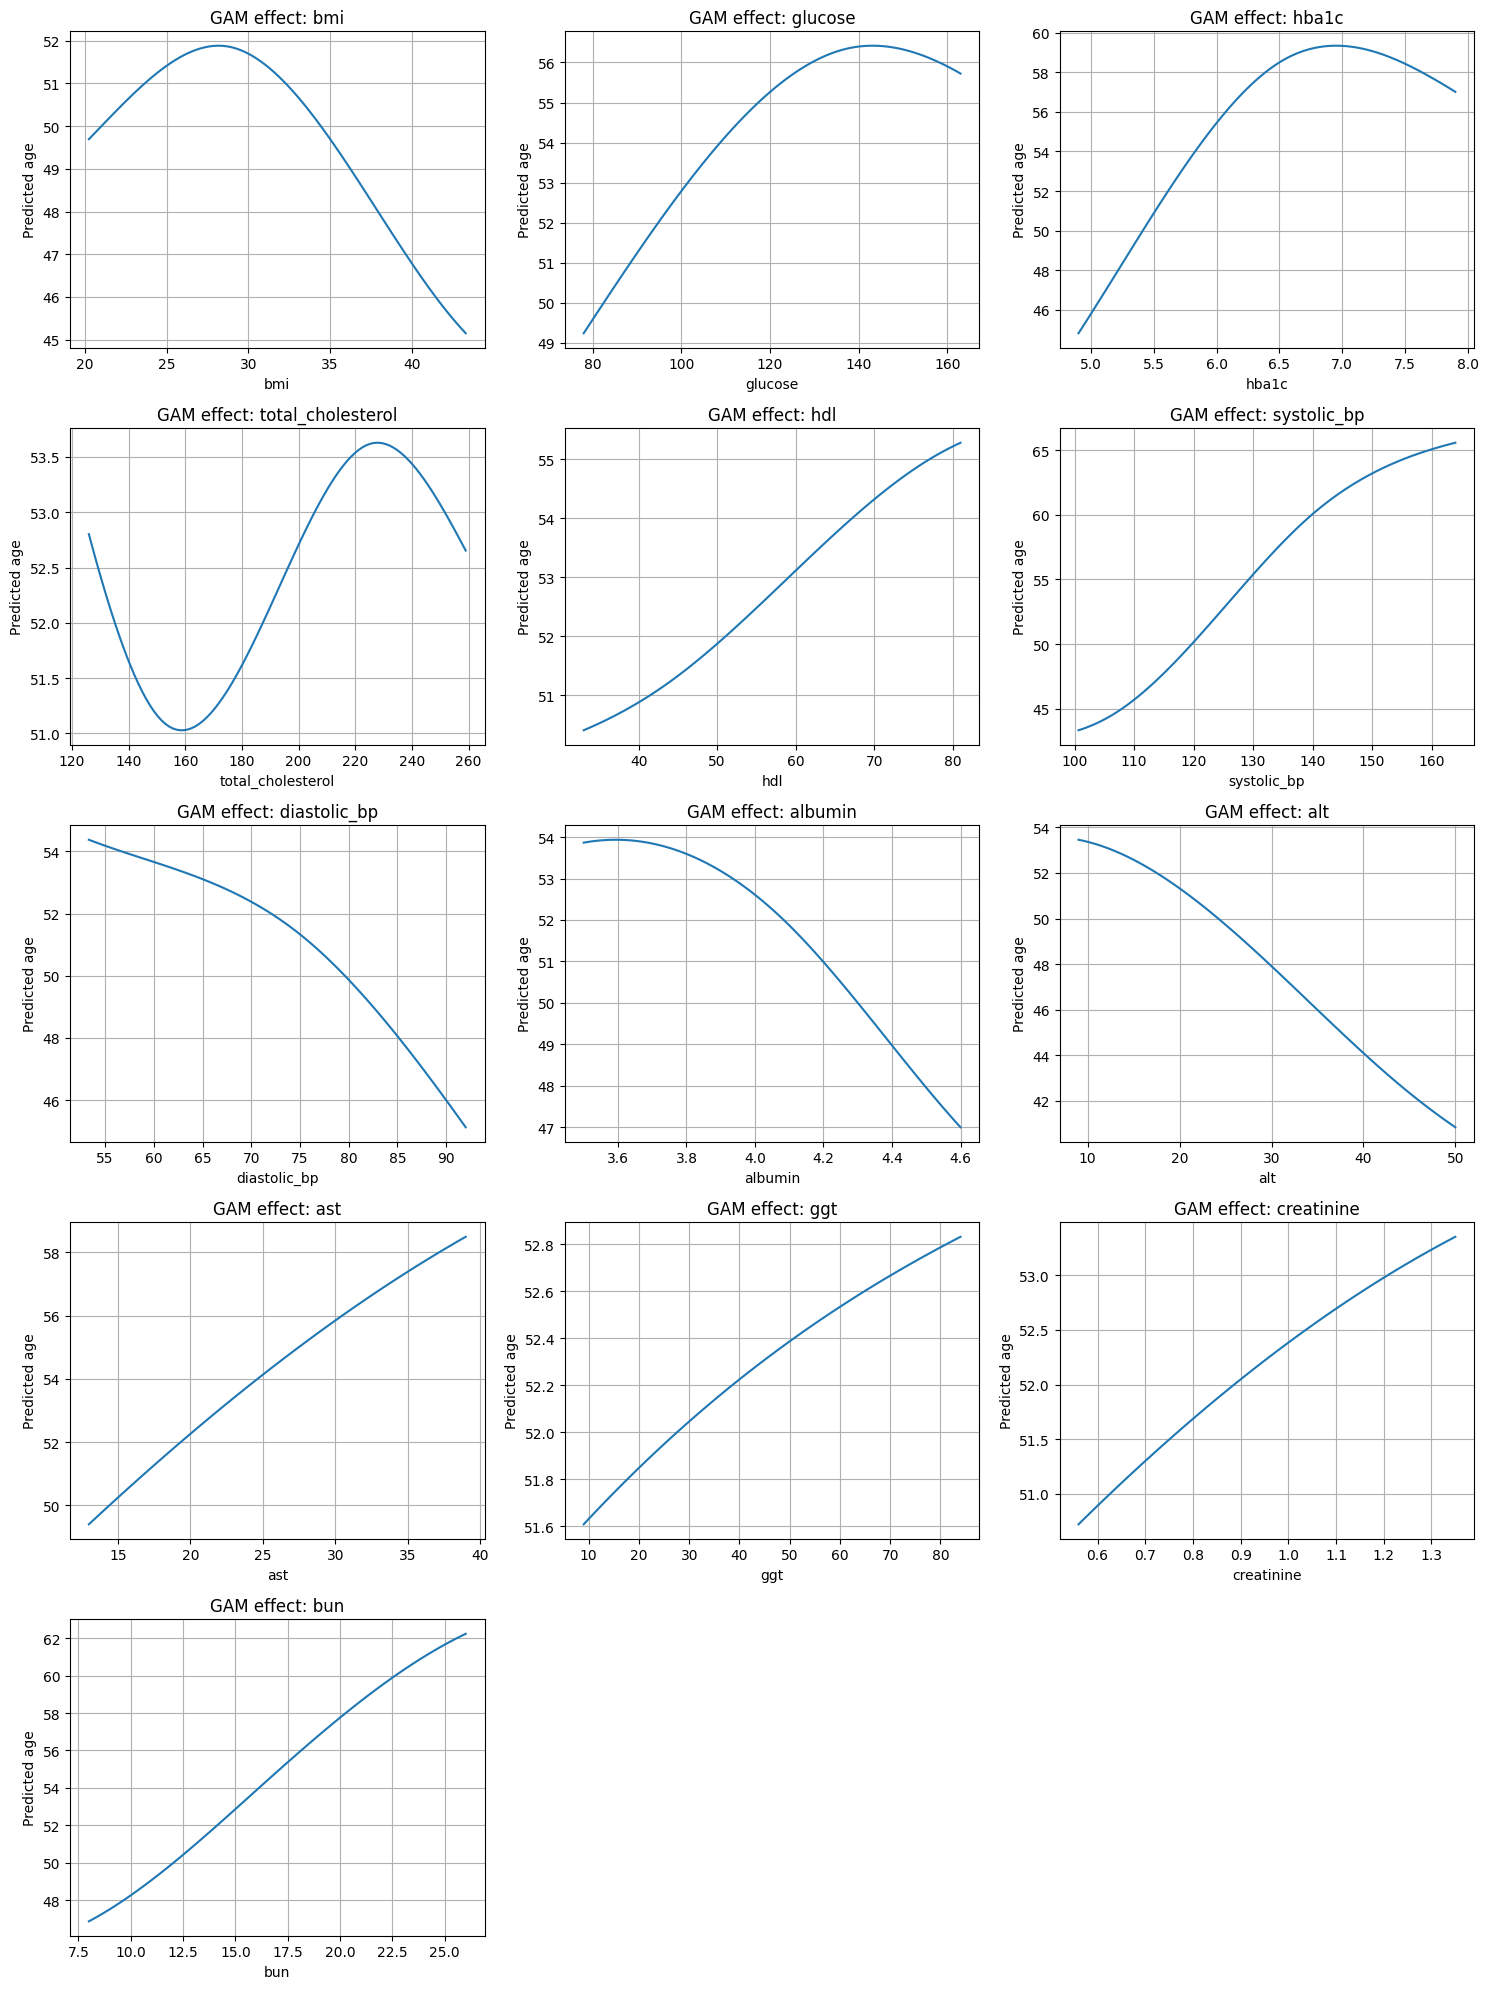

In [124]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(15, 20)
)

axes = axes.flatten()

# Start with a representative person
base_person = X_train.median(numeric_only=True).to_dict()

# Use the most common sex
base_person["sex"] = X_train["sex"].mode()[0]

for i, feature in enumerate(numerical_features):

    # Use the 5th to 95th percentile
    values = np.linspace(
        X_train[feature].quantile(0.05),
        X_train[feature].quantile(0.95),
        100
    )

    plot_data = pd.DataFrame(
        [base_person] * len(values)
    )

    plot_data[feature] = values

    predictions = gam_model.predict(plot_data)

    axes[i].plot(
        values,
        predictions
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Predicted age")
    axes[i].set_title(f"GAM effect: {feature}")
    axes[i].grid(True)

# Remove unused subplot
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ["sex"]

numerical_features = [
    "bmi",
    "glucose",
    "hba1c",
    "total_cholesterol",
    "hdl",
    "systolic_bp",
    "diastolic_bp",
    "albumin",
    "alt",
    "ast",
    "ggt",
    "creatinine",
    "bun"
]

mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [126]:
from sklearn.neural_network import MLPRegressor

mlp_model = Pipeline([
    ("preprocessor", mlp_preprocessor),

    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20
    ))
])

In [127]:
mlp_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [128]:
[name for name in globals() if "mlp" in name.lower()]

['mlp_preprocessor',
 'MLPRegressor',
 'mlp_model',
 'y_pred_mlp',
 'mae_mlp',
 'rmse_mlp',
 'r2_mlp',
 'mlp_cv',
 'mlp_cv_mae',
 'mlp_cv_rmse',
 'mlp_cv_r2',
 'mlp_preprocessor_fitted',
 'mlp_estimator']

In [129]:
y_pred_mlp = mlp_model.predict(X_test)

In [130]:
[name for name in globals() if "mlp" in name.lower()]

['mlp_preprocessor',
 'MLPRegressor',
 'mlp_model',
 'y_pred_mlp',
 'mae_mlp',
 'rmse_mlp',
 'r2_mlp',
 'mlp_cv',
 'mlp_cv_mae',
 'mlp_cv_rmse',
 'mlp_cv_r2',
 'mlp_preprocessor_fitted',
 'mlp_estimator']

In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

rmse_mlp = np.sqrt(
    mean_squared_error(y_test, y_pred_mlp)
)

r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP")
print("-----------------")
print("MAE :", mae_mlp)
print("RMSE:", rmse_mlp)
print("R²  :", r2_mlp)

MLP
-----------------
MAE : 8.347059741020866
RMSE: 10.607983855295782
R²  : 0.6379168413857218


In [132]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GAM",
        "MLP"
    ],
    "MAE": [
        mae_linear,
        mae_gam,
        mae_mlp
    ],
    "RMSE": [
        rmse_linear,
        rmse_gam,
        rmse_mlp
    ],
    "R2": [
        r2_linear,
        r2_gam,
        r2_mlp
    ]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  10.791538  13.295435  0.431216
1                GAM   9.273186  11.422008  0.580214
2                MLP   8.347060  10.607984  0.637917


In [133]:
from sklearn.model_selection import KFold, cross_validate

In [134]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [135]:
linear_cv = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

In [136]:
linear_cv_mae = -linear_cv["test_MAE"]
linear_cv_rmse = -linear_cv["test_RMSE"]
linear_cv_r2 = linear_cv["test_R2"]

print("Linear Regression CV")
print("MAE :", linear_cv_mae.mean())
print("RMSE:", linear_cv_rmse.mean())
print("R²  :", linear_cv_r2.mean())

Linear Regression CV
MAE : 10.997558664180497
RMSE: 13.415851553220984
R²  : 0.4141722146731027


In [137]:
print("\nStandard deviation")
print("MAE :", linear_cv_mae.std())
print("RMSE:", linear_cv_rmse.std())
print("R²  :", linear_cv_r2.std())


Standard deviation
MAE : 0.2929545863541585
RMSE: 0.33550543406909145
R²  : 0.02859808872457073


In [138]:
gam_cv = cross_validate(
    gam_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

In [139]:
gam_cv_mae = -gam_cv["test_MAE"]
gam_cv_rmse = -gam_cv["test_RMSE"]
gam_cv_r2 = gam_cv["test_R2"]

print("GAM CV")
print("MAE :", gam_cv_mae.mean())
print("RMSE:", gam_cv_rmse.mean())
print("R²  :", gam_cv_r2.mean())

print("\nStandard deviation")
print("MAE :", gam_cv_mae.std())
print("RMSE:", gam_cv_rmse.std())
print("R²  :", gam_cv_r2.std())

GAM CV
MAE : 9.51286373547865
RMSE: 11.800951350006844
R²  : 0.5465456246221649

Standard deviation
MAE : 0.23733104226224747
RMSE: 0.26813095984179214
R²  : 0.024525227999911924


In [140]:
mlp_cv = cross_validate(
    mlp_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

In [141]:
mlp_cv_mae = -mlp_cv["test_MAE"]
mlp_cv_rmse = -mlp_cv["test_RMSE"]
mlp_cv_r2 = mlp_cv["test_R2"]

print("MLP CV")
print("MAE :", mlp_cv_mae.mean())
print("RMSE:", mlp_cv_rmse.mean())
print("R²  :", mlp_cv_r2.mean())

print("\nStandard deviation")
print("MAE :", mlp_cv_mae.std())
print("RMSE:", mlp_cv_rmse.std())
print("R²  :", mlp_cv_r2.std())


MLP CV
MAE : 8.869234708700414
RMSE: 11.333287215846648
R²  : 0.5817995875494228

Standard deviation
MAE : 0.16329276699833875
RMSE: 0.2928963110927641
R²  : 0.023325751044288263


In [142]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GAM",
        "MLP"
    ],
    "CV_MAE": [
        linear_cv_mae.mean(),
        gam_cv_mae.mean(),
        mlp_cv_mae.mean()
    ],
    "CV_RMSE": [
        linear_cv_rmse.mean(),
        gam_cv_rmse.mean(),
        mlp_cv_rmse.mean()
    ],
    "CV_R2": [
        linear_cv_r2.mean(),
        gam_cv_r2.mean(),
        mlp_cv_r2.mean()
    ],
    "MAE_SD": [
        linear_cv_mae.std(),
        gam_cv_mae.std(),
        mlp_cv_mae.std()
    ],
    "RMSE_SD": [
        linear_cv_rmse.std(),
        gam_cv_rmse.std(),
        mlp_cv_rmse.std()
    ],
    "R2_SD": [
        linear_cv_r2.std(),
        gam_cv_r2.std(),
        mlp_cv_r2.std()
    ]
})

print(cv_results)

               Model     CV_MAE    CV_RMSE     CV_R2    MAE_SD   RMSE_SD  \
0  Linear Regression  10.997559  13.415852  0.414172  0.292955  0.335505   
1                GAM   9.512864  11.800951  0.546546  0.237331  0.268131   
2                MLP   8.869235  11.333287  0.581800  0.163293  0.292896   

      R2_SD  
0  0.028598  
1  0.024525  
2  0.023326  


In [143]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [144]:
mlp_preprocessor_fitted = mlp_model.named_steps["preprocessor"]
mlp_estimator = mlp_model.named_steps["model"]

In [145]:
X_train_transformed = mlp_preprocessor_fitted.transform(X_train)
X_test_transformed = mlp_preprocessor_fitted.transform(X_test)

In [146]:
print(X_train_transformed.shape)
print(X_test_transformed.shape)

(3687, 14)
(922, 14)


In [147]:
feature_names = mlp_preprocessor_fitted.get_feature_names_out()

print(feature_names)

['numeric__bmi' 'numeric__glucose' 'numeric__hba1c'
 'numeric__total_cholesterol' 'numeric__hdl' 'numeric__systolic_bp'
 'numeric__diastolic_bp' 'numeric__albumin' 'numeric__alt' 'numeric__ast'
 'numeric__ggt' 'numeric__creatinine' 'numeric__bun'
 'categorical__sex_2.0']


In [148]:
background = X_train_transformed[:100]

explainer = shap.KernelExplainer(
    mlp_estimator.predict,
    background
)

In [149]:
X_shap = X_test_transformed[:200]

shap_values = explainer.shap_values(
    X_shap
)

100%|██████████| 200/200 [00:27<00:00,  7.31it/s]


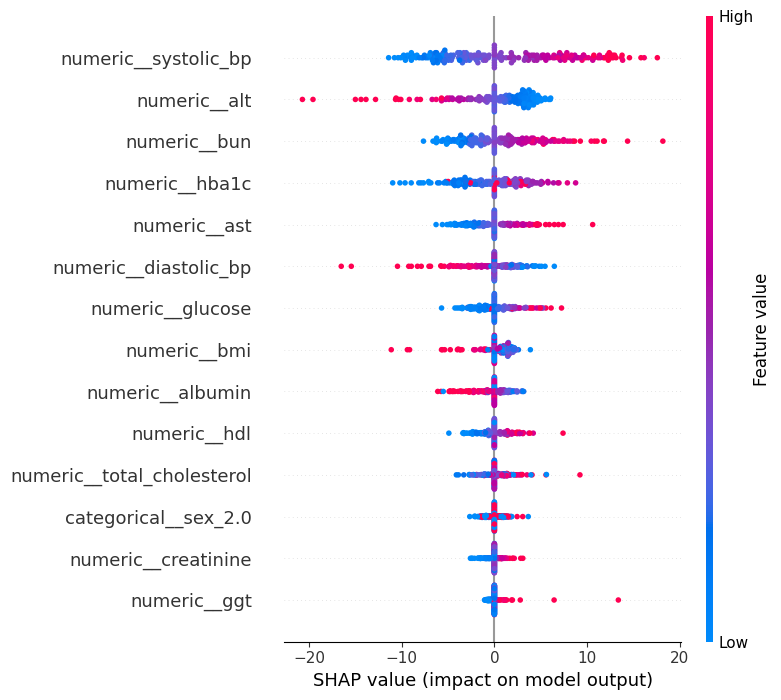

In [150]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

In [151]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

print(shap_importance)

                       Feature  Mean_Absolute_SHAP
5         numeric__systolic_bp            5.936956
8                 numeric__alt            3.344357
12                numeric__bun            3.337281
2               numeric__hba1c            2.775131
9                 numeric__ast            2.032061
6        numeric__diastolic_bp            1.943061
1             numeric__glucose            1.479639
0                 numeric__bmi            1.311199
7             numeric__albumin            1.271312
4                 numeric__hdl            1.109780
3   numeric__total_cholesterol            0.866041
13        categorical__sex_2.0            0.641722
11         numeric__creatinine            0.407552
10                numeric__ggt            0.283095


In [152]:
print(shap_importance)

                       Feature  Mean_Absolute_SHAP
5         numeric__systolic_bp            5.936956
8                 numeric__alt            3.344357
12                numeric__bun            3.337281
2               numeric__hba1c            2.775131
9                 numeric__ast            2.032061
6        numeric__diastolic_bp            1.943061
1             numeric__glucose            1.479639
0                 numeric__bmi            1.311199
7             numeric__albumin            1.271312
4                 numeric__hdl            1.109780
3   numeric__total_cholesterol            0.866041
13        categorical__sex_2.0            0.641722
11         numeric__creatinine            0.407552
10                numeric__ggt            0.283095


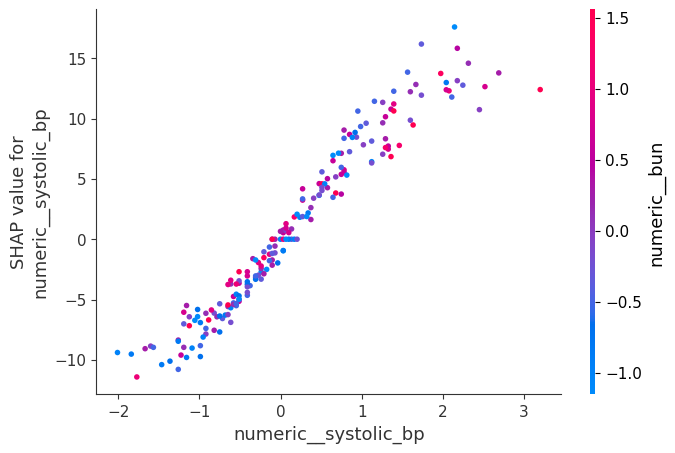

In [153]:
shap.dependence_plot(
    "numeric__systolic_bp",
    shap_values,
    X_shap,
    feature_names=feature_names
)

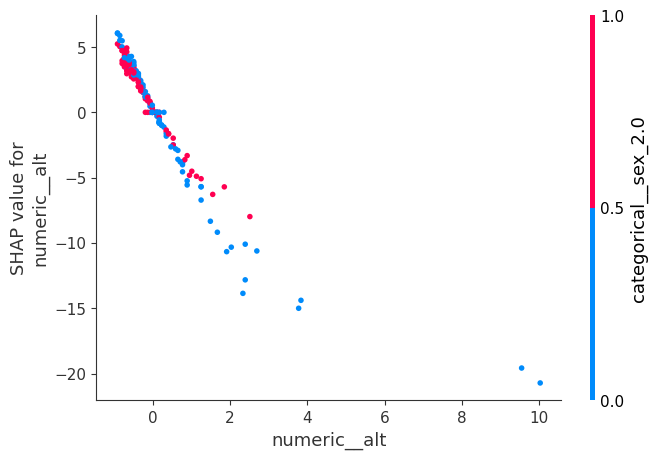

In [154]:
shap.dependence_plot(
    "numeric__alt",
    shap_values,
    X_shap,
    feature_names=feature_names
)

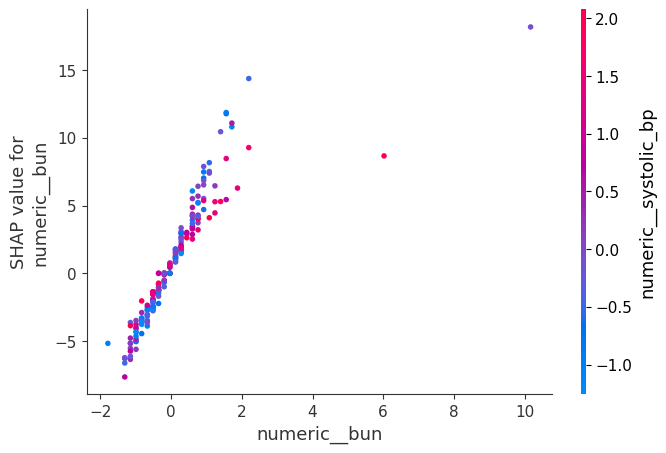

In [155]:
shap.dependence_plot(
    "numeric__bun",
    shap_values,
    X_shap,
    feature_names=feature_names
)

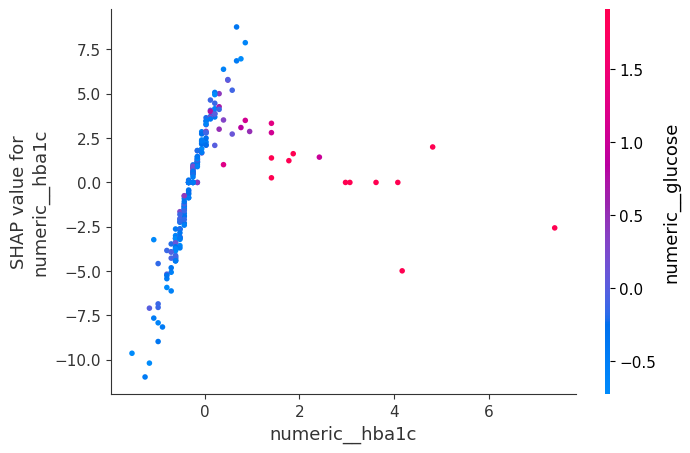

In [156]:
shap.dependence_plot(
    "numeric__hba1c",
    shap_values,
    X_shap,
    feature_names=feature_names
)

In [157]:
import pandas as pd
import numpy as np

features_to_compare = [
    "creatinine",
    "diastolic_bp",
    "alt",
    "ast",
    "bmi"
]

def extract_gam_curves(gam_model, X_train, features, n_points=200):

    curves = []

    # Reference participant
    base_person = X_train.median(numeric_only=True).to_dict()
    base_person["sex"] = X_train["sex"].mode()[0]

    for feature in features:

        low = X_train[feature].quantile(0.05)
        high = X_train[feature].quantile(0.95)

        values = np.linspace(low, high, n_points)

        plot_data = pd.DataFrame(
            [base_person] * n_points
        )

        plot_data[feature] = values

        predictions = gam_model.predict(plot_data)

        # Centre curve so we compare SHAPE,
        # rather than absolute baseline age
        centred_effect = predictions - predictions.mean()

        temp = pd.DataFrame({
            "Feature": feature,
            "Value": values,
            "Effect": centred_effect
        })

        curves.append(temp)

    return pd.concat(curves, ignore_index=True)


pre_gam_curves = extract_gam_curves(
    gam_model,
    X_train,
    features_to_compare
)

pre_gam_curves["Period"] = "Pre-pandemic"

pre_gam_curves.to_csv(
    "pre_gam_curves.csv",
    index=False
)

print(pre_gam_curves.head())

      Feature     Value    Effect        Period
0  creatinine  0.560000 -1.449981  Pre-pandemic
1  creatinine  0.563970 -1.432898  Pre-pandemic
2  creatinine  0.567940 -1.415850  Pre-pandemic
3  creatinine  0.571910 -1.398838  Pre-pandemic
4  creatinine  0.575879 -1.381861  Pre-pandemic


In [158]:
from sklearn.inspection import permutation_importance
import pandas as pd

pre_perm = permutation_importance(
    mlp_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

pre_perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Pre_Permutation": pre_perm.importances_mean,
    "Pre_SD": pre_perm.importances_std
}).sort_values(
    "Pre_Permutation",
    ascending=False
)

print(pre_perm_df.round(4).to_string(index=False))

pre_perm_df.to_csv(
    "pre_permutation_importance.csv",
    index=False
)

          Feature  Pre_Permutation  Pre_SD
      systolic_bp           0.3983  0.0237
            hba1c           0.1667  0.0146
              bun           0.1317  0.0106
              alt           0.1173  0.0101
     diastolic_bp           0.0938  0.0101
          glucose           0.0637  0.0094
          albumin           0.0526  0.0079
              ast           0.0469  0.0075
              bmi           0.0401  0.0061
total_cholesterol           0.0358  0.0083
              sex           0.0306  0.0055
              hdl           0.0218  0.0047
       creatinine           0.0122  0.0042
              ggt           0.0116  0.0059


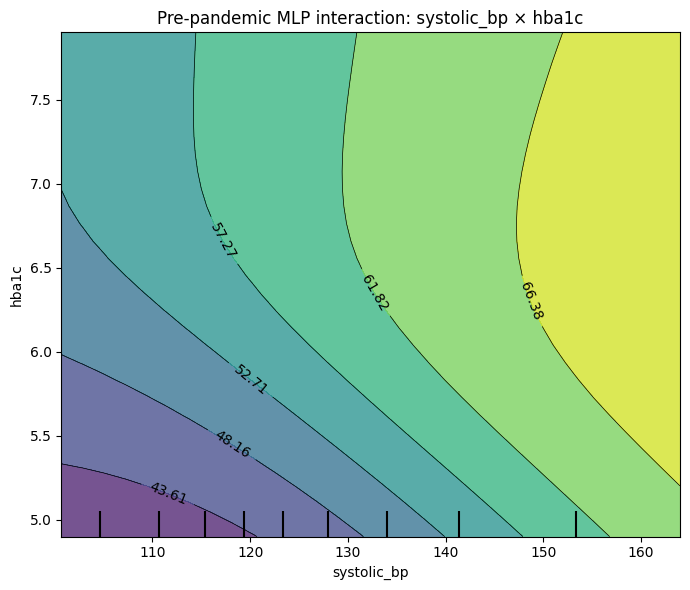

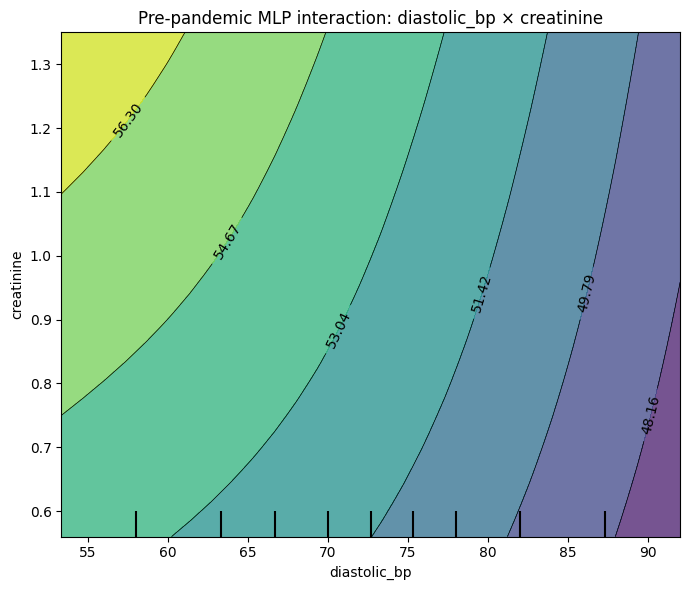

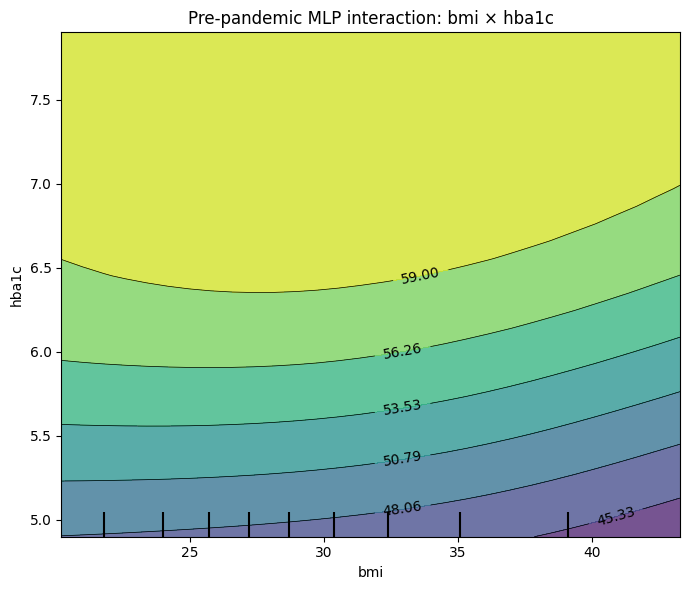

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

interaction_pairs = [
    ("systolic_bp", "hba1c"),
    ("diastolic_bp", "creatinine"),
    ("bmi", "hba1c")
]

for pair in interaction_pairs:
    fig, ax = plt.subplots(figsize=(7, 6))

    PartialDependenceDisplay.from_estimator(
        mlp_model,
        X_train,
        features=[pair],
        kind="average",
        grid_resolution=30,
        ax=ax
    )

    ax.set_title(
        f"Pre-pandemic MLP interaction: "
        f"{pair[0]} × {pair[1]}"
    )

    plt.tight_layout()
    plt.show()